In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# loading data from s3 
df = pd.read_csv("s3://telechurn360-raw/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# basic info of the dataset 

In [3]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# data cleaning

In [6]:

# Fix TotalCharges (has hidden spaces causing errors)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [44]:
# Filling missing TotalCharges with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [45]:
# Convert Churn to 0/1 values so it helps with analysis
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [46]:
# Droping  customerID as it has no use for analysis
df.drop(columns=['customerID'], inplace=True)


KeyError: "['customerID'] not found in axis"

In [ ]:
# Verify no missing values remain
print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# churn rate and retention rate for total customers

churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Churn Rate    : {churn_rate[1]:.1f}%")
print(f"Retention Rate: {churn_rate[0]:.1f}%")
print(f"Total Customers: {len(df)}")



Churn Rate    : 26.5%
Retention Rate: 73.5%
Total Customers: 7043


# feature engineering

In [ ]:
# Group customers based on how long they have stayed
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 48, 72],
                             labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'])

In [ ]:
# Group customers by monthly spending to analyze its impact on churn rate 
df['charges_group'] = pd.cut(df['MonthlyCharges'],
                              bins=[0, 35, 65, 100],
                              labels=['Low', 'Medium', 'High'])

In [ ]:
# Counting total  no of services per customer to measure its engagement level
df['total_services'] = (
    (df['PhoneService'] == 'Yes').astype(int) +
    (df['MultipleLines'] == 'Yes').astype(int) +
    (df['InternetService'] != 'No').astype(int) +
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int) +
    (df['TechSupport'] == 'Yes').astype(int) +
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

In [ ]:
# checkign of customers have long term contract
df['is_longterm'] = df['Contract'].apply(
    lambda x: 1 if x in ['One year', 'Two year'] else 0)

In [ ]:
# Flaging high-risk customers based on short contract and high monthly charges
df['high_risk'] = (
    (df['Contract'] == 'Month-to-month') &
    (df['MonthlyCharges'] > 65)
).astype(int)


In [ ]:
# Average monthly spend per tenure year
df['avg_spend_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# VISUALIZATION

/var/folders/0_/q7hlfhcn723fzh10jym7md6c0000gn/T/ipykernel_95933/2858645097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'coral'])


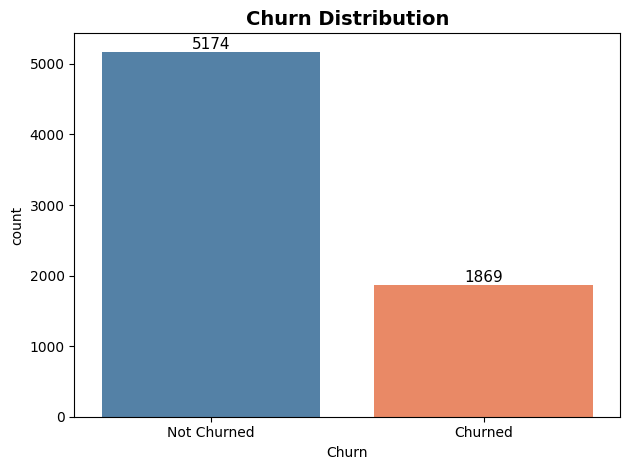

In [ ]:
# 1. Churn Distribution
plt.figure()
ax = sns.countplot(x='Churn', data=df, palette=['steelblue', 'coral'])
plt.title("Churn Distribution", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}'
                ,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig("plot1_churn_distribution.png", dpi=150)
plt.show()

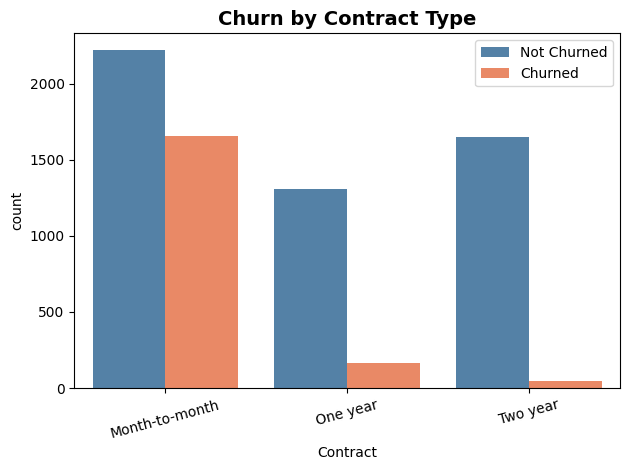

In [ ]:
# 2. Contract Type vs Churn
plt.figure()
sns.countplot(x='Contract', hue='Churn', data=df, palette=['steelblue', 'coral'])
plt.title("Churn by Contract Type", fontsize=14, fontweight='bold')
plt.xticks(rotation=15)
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.savefig("plot2_contract_churn.png", dpi=150)
plt.show()


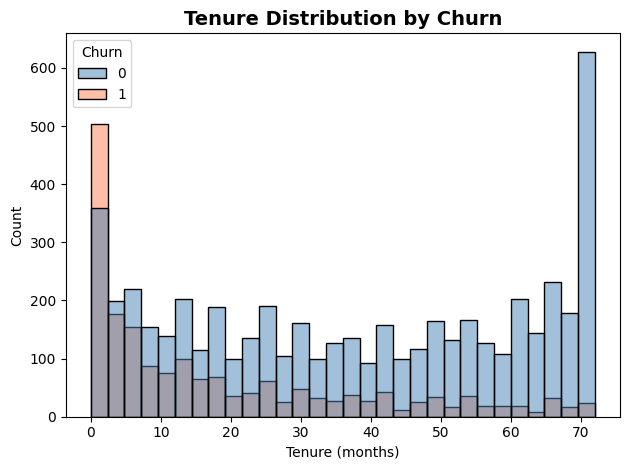

In [ ]:
# 3. Tenure Distribution by Churn
plt.figure()
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette=['steelblue', 'coral'])
plt.title("Tenure Distribution by Churn", fontsize=14, fontweight='bold')
plt.xlabel("Tenure (months)")
plt.tight_layout()
plt.savefig("plot3_tenure_churn.png", dpi=150)
plt.show()

/var/folders/0_/q7hlfhcn723fzh10jym7md6c0000gn/T/ipykernel_95933/285829058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['steelblue', 'coral'])


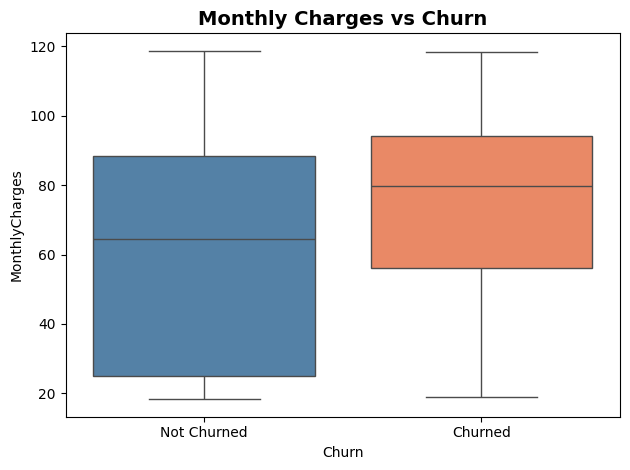

In [ ]:

# 4. Monthly Charges vs Churn
plt.figure()
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['steelblue', 'coral'])
plt.title("Monthly Charges vs Churn", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.tight_layout()
plt.savefig("plot4_charges_churn.png", dpi=150)
plt.show()

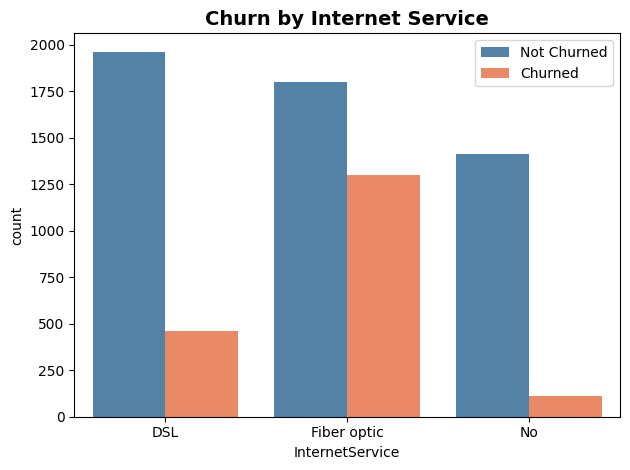

In [ ]:

# 5. Internet Service vs Churn
plt.figure()
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['steelblue', 'coral'])
plt.title("Churn by Internet Service", fontsize=14, fontweight='bold')
plt.legend(['Not Churned', 'Churned'])
plt.tight_layout()
plt.savefig("plot5_internet_churn.png", dpi=150)
plt.show()

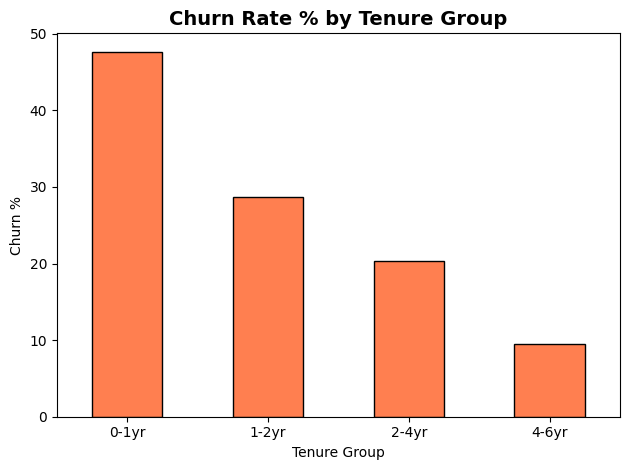

In [ ]:
# 6. Tenure Group vs Churn Rate
plt.figure()
tenure_churn_plot = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
tenure_churn_plot.plot(kind='bar', color='coral', edgecolor='black')
plt.title("Churn Rate % by Tenure Group", fontsize=14, fontweight='bold')
plt.ylabel("Churn %")
plt.xlabel("Tenure Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot6_tenure_group_churn.png", dpi=150)
plt.show()

/var/folders/0_/q7hlfhcn723fzh10jym7md6c0000gn/T/ipykernel_95933/627375689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='total_services', data=df, palette=['steelblue', 'coral'])


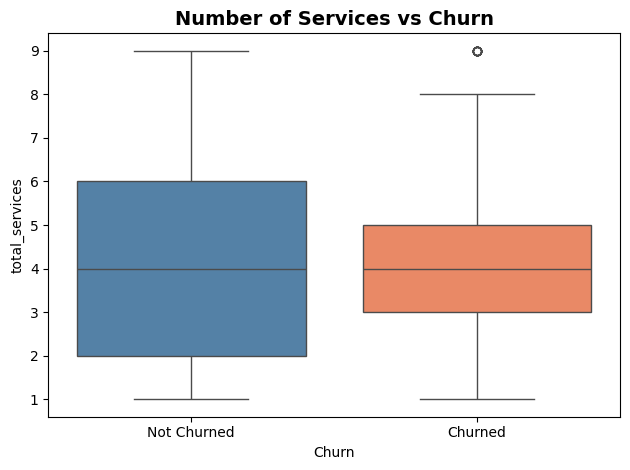

In [ ]:
# 7. Total Services vs Churn
plt.figure()
sns.boxplot(x='Churn', y='total_services', data=df, palette=['steelblue', 'coral'])
plt.title("Number of Services vs Churn", fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Not Churned', 'Churned'])
plt.tight_layout()
plt.savefig("plot7_services_churn.png", dpi=150)
plt.show()

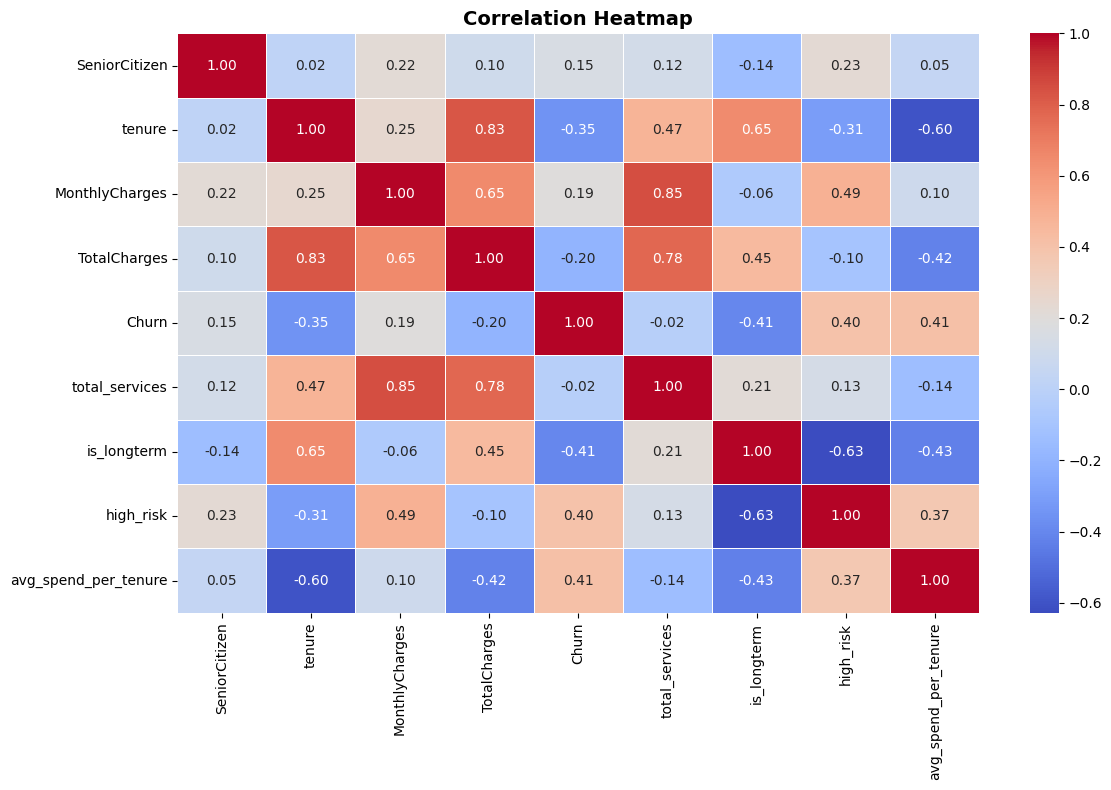

In [ ]:
# 8. Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot8_correlation_heatmap.png", dpi=150)
plt.show()

# INSIGHTS

In [ ]:
# Churn % by Contract
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print("\nChurn % by Contract Type:")
print(contract_churn.round(1).to_string())


Churn % by Contract Type:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8


In [47]:
# Churn % by Tenure Group
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean() * 100
print("\nChurn % by Tenure Group:")
print(tenure_churn.round(1).to_string())


Churn % by Tenure Group:
tenure_group
0-1yr   NaN
1-2yr   NaN
2-4yr   NaN
4-6yr   NaN


In [28]:
# Churn % by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
print("\nChurn % by Payment Method:")
print(payment_churn.round(1).to_string())


Churn % by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1


In [29]:
# Churn % by Charges Group
charges_churn = df.groupby('charges_group', observed=True)['Churn'].mean() * 100
print("\nChurn % by Monthly Charges Group:")
print(charges_churn.round(1).to_string())


Churn % by Monthly Charges Group:
charges_group
Low       10.9
Medium    23.1
High      36.7


In [30]:
# Revenue impact
revenue_loss = df[df['Churn'] == 1]['MonthlyCharges'].sum()
total_revenue = df['MonthlyCharges'].sum()
loss_pct = (revenue_loss / total_revenue) * 100
print(f"\nMonthly Revenue Lost to Churn : ${revenue_loss:,.0f}")
print(f"Total Monthly Revenue         : ${total_revenue:,.0f}")
print(f"Revenue Loss %                : {loss_pct:.1f}%")



Monthly Revenue Lost to Churn : $139,131
Total Monthly Revenue         : $456,117
Revenue Loss %                : 30.5%


In [31]:
# High risk customers
high_risk_count = df['high_risk'].sum()
high_risk_churn = df[df['high_risk'] == 1]['Churn'].mean() * 100
print(f"\nHigh Risk Customers           : {high_risk_count}")
print(f"Churn Rate among High Risk    : {high_risk_churn:.1f}%")


High Risk Customers           : 2292
Churn Rate among High Risk    : 51.7%


In [43]:
# saving cleaned dataset as csv
df.to_csv("churn_cleaned.csv", index=False)

# KEY INSIGHTS 

In [32]:
print(f"""
1. New customers are the biggest concern.
   Almost half (47.7%) leave within the first year.

2. Month-to-month contracts are risky.
   42.7% churn vs just 2.8% on 2-year plans.
   Encouraging long-term contracts can reduce churn.

3. Electronic check users churn the most (45.3%).
   Auto-pay users are much more loyal (~16%).

4. High-paying customers are also leaving.
   Despite higher spending, 36.7% of them churn.

5. 2,292 customers are at high risk.
   They are on monthly plans with high charges.
   Over half of them may churn if no action is taken.

6. The real cost: $139,131 lost every month.
   That’s over $1.6 million annually.
""")


1. New customers are the biggest concern.
   Almost half (47.7%) leave within the first year.

2. Month-to-month contracts are risky.
   42.7% churn vs just 2.8% on 2-year plans.
   Encouraging long-term contracts can reduce churn.

3. Electronic check users churn the most (45.3%).
   Auto-pay users are much more loyal (~16%).

4. High-paying customers are also leaving.
   Despite higher spending, 36.7% of them churn.

5. 2,292 customers are at high risk.
   They are on monthly plans with high charges.
   Over half of them may churn if no action is taken.

6. The real cost: $139,131 lost every month.
   That’s over $1.6 million annually.

